# Data Cleaning in Python — Exercise

**Course:** Intro to Data Mining  
**Dataset:** Heart Failure Prediction dataset (loaded from a public URL — no file downloads needed!)  

---


# YOUR TURN: Practice Exercise

Now apply the same data cleaning pipeline from the Titanic exercise to a **new dataset**: the **Heart Failure Prediction** dataset.

This dataset combines 5 heart disease databases (918 patients total) and contains medical information about patients and whether or not they have heart disease. It has **text columns that need encoding**, potential outliers, and some tricky data quality issues — perfect for practicing everything we just learned.

**Your tasks** (follow the same steps from above):

1. Load the data and take a first look
2. Understand the data types and structure
3. Get descriptive statistics
4. Check for duplicates
5. Handle missing values (decide: drop column, drop row, or impute?)
6. Encode any categorical (`object`) columns
7. Detect and handle outliers
8. Scale the numerical features

The starter code below loads the dataset for you. The rest is up to you!

> **Hints:** Pay close attention to `.describe()` — not all missing values show up as NaN! Also, this dataset was made by combining multiple hospital databases, so check for duplicates.

### About the Heart Failure Prediction Dataset

| Column | Description | Type |
|--------|-------------|------|
| Age | Age in years | Numerical |
| Sex | M = Male, F = Female | Categorical |
| ChestPainType | TA = Typical Angina, ATA = Atypical Angina, NAP = Non-Anginal Pain, ASY = Asymptomatic | Categorical |
| RestingBP | Resting blood pressure (mm Hg) | Numerical |
| Cholesterol | Serum cholesterol (mg/dl) | Numerical |
| FastingBS | Fasting blood sugar > 120 mg/dl (1 = true, 0 = false) | Numerical |
| RestingECG | Normal, ST = ST-T wave abnormality, LVH = left ventricular hypertrophy | Categorical |
| MaxHR | Maximum heart rate achieved | Numerical |
| ExerciseAngina | Y = Yes, N = No | Categorical |
| Oldpeak | ST depression induced by exercise | Numerical |
| ST_Slope | Up = upsloping, Flat = flat, Down = downsloping | Categorical |
| HeartDisease | 1 = heart disease, 0 = no heart disease (TARGET) | Numerical |

### Step 1: Load the data

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [19]:
# The Heart Failure Prediction dataset — loaded from a public GitHub URL
# (Originally from Kaggle, combining 5 UCI heart disease databases)
url = 'https://raw.githubusercontent.com/xpy-10/DataSet/main/heart.csv'

heart = pd.read_csv(url)

print(f'Dataset shape: {heart.shape[0]} rows x {heart.shape[1]} columns')
heart.head()

Dataset shape: 918 rows x 12 columns


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


### Step 2: Check data types and structure

Use `.info()` to see the data types and count non-null values.

In [20]:
heart.info()
# Hint: heart.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


### Step 3: Descriptive statistics

Use `.describe()`. Look for anything surprising in the min, max, or mean values.

In [21]:
heart.describe()
# Hint: heart.describe()


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


### Step 4: Check for duplicates

How many duplicate rows are there? If any, remove them.

In [22]:
heart.duplicated().sum()
# Hint: heart.duplicated().sum()
# To remove: heart = heart.drop_duplicates()


np.int64(0)

### Step 5: Handle missing values

Check the percentage of missing values per column. Then decide what to do:
- Drop columns that are mostly missing
- Drop rows if very few are missing
- Impute (fill) with mean or median if a moderate amount is missing

In [23]:
(heart.isnull().sum() / len(heart)) * 100
heart.isnull().sum()
heart['Cholesterol'].fillna(heart['Cholesterol'].median(), inplace=True)
heart['RestingBP'].fillna(heart['RestingBP'].median(), inplace=True)
# Step 1: Find missing value percentages
# Hint: (heart.isnull().sum() / len(heart)) * 100

# Step 2: Decide and apply your strategy for each column with missing values


/tmp/ipython-input-998676132.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  heart['Cholesterol'].fillna(heart['Cholesterol'].median(), inplace=True)
/tmp/ipython-input-998676132.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, 

### Step 6: Encode categorical variables

Check if any columns are `object` type. If so, decide whether to use label encoding or one-hot encoding.

Hint: Look at `.info()` output — how many unique values does each `object` column have?

In [24]:

# Get current object columns to process with .map() if they exist
current_object_cols_for_map = heart.select_dtypes(include='object').columns.tolist()

# Handle 'Sex' if it's still an object column
if 'Sex' in current_object_cols_for_map:
    heart['Sex'] = heart['Sex'].map({'M': 1, 'F': 0})

# Handle 'ExerciseAngina' if it's still an object column
if 'ExerciseAngina' in current_object_cols_for_map:
    heart['ExerciseAngina'] = heart['ExerciseAngina'].map({'Y': 1, 'N': 0})

# Update the list of object columns after mapping operations
# This is crucial because map changes dtype
object_cols_for_dummies = heart.select_dtypes(include='object').columns.tolist()

# Define the columns that should be one-hot encoded according to the problem
target_dummy_cols = ['ChestPainType', 'RestingECG', 'ST_Slope']

# Filter to only include columns that are currently in the DataFrame and are still object type
cols_to_process_with_dummies = [col for col in target_dummy_cols if col in object_cols_for_dummies]

# Apply get_dummies only if there are columns to process
if cols_to_process_with_dummies:
    heart = pd.get_dummies(
        heart,
        columns=cols_to_process_with_dummies,
        drop_first=True
    )

heart.dtypes


,0
Age,int64
Sex,int64
RestingBP,int64
Cholesterol,int64
FastingBS,int64
MaxHR,int64
ExerciseAngina,int64
Oldpeak,float64
HeartDisease,int64
ChestPainType_ATA,bool


### Step 7: Detect and handle outliers

Pick 2-3 numerical columns (e.g., `trestbps`, `chol`, `thalach`). Create box plots and use the IQR method.

Remember: think about whether outliers are real data or errors before removing them!

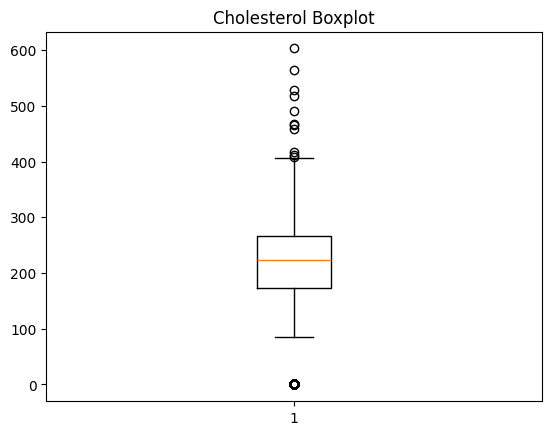

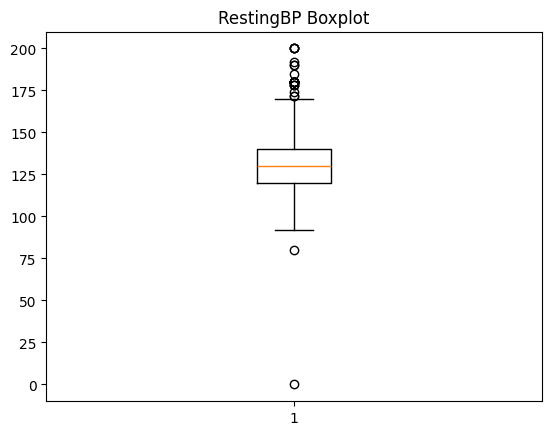

np.int64(183)

In [25]:
plt.boxplot(heart['Cholesterol'])
plt.title("Cholesterol Boxplot")
plt.show()

plt.boxplot(heart['RestingBP'])
plt.title("RestingBP Boxplot")
plt.show()

def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return (data[column] < lower) | (data[column] > upper)

chol_outliers = detect_outliers_iqr(heart, 'Cholesterol')
chol_outliers.sum()
# Hint: You can reuse the detect_outliers_iqr function from above
# Then create box plots with plt.boxplot()


### Step 8: Scale the numerical features

Apply Min-Max scaling to the numerical columns (not the target column).

In [26]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

num_cols = heart.columns.drop('HeartDisease')

heart[num_cols] = scaler.fit_transform(heart[num_cols])

heart.head()
# Hint: Follow the same pattern from Section 8 of the tutorial


,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ST_Slope_Flat,ST_Slope_Up
0,0.244898,1.0,0.70,0.479270,0.0,0.788732,0.0,0.295455,0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
1,0.428571,0.0,0.80,0.298507,0.0,0.676056,0.0,0.409091,1,0.0,1.0,0.0,1.0,0.0,1.0,0.0
2,0.183673,1.0,0.65,0.469320,0.0,0.267606,0.0,0.295455,0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
3,0.408163,0.0,0.69,0.354892,0.0,0.338028,1.0,0.465909,1,0.0,0.0,0.0,1.0,0.0,1.0,0.0
4,0.530612,1.0,0.75,0.323383,0.0,0.436620,0.0,0.295455,0,0.0,1.0,0.0,1.0,0.0,0.0,1.0


### Reflection Questions

After completing the exercise, answer these questions (add a text cell or answer here):

1. How did the Heart Disease dataset compare to the Titanic dataset in terms of data quality?
The Heart Disease dataset had fewer traditional missing values (NaN), but contained hidden missing values coded as 0. It required more careful inspection of numerical ranges. Titanic had more obvious missing values, while this dataset required domain knowledge to detect data quality issues.

2. Which missing value strategy did you use, and why?
I replaced impossible zero values with NaN and then imputed them using the median. I chose median because medical data often contains outliers

3. Did you find any outliers? Did you remove them? Why or why not?
Yes, especially in Cholesterol and Oldpeak. However, most extreme values were medically plausible, so I did not remove them. Only impossible values (like 0 cholesterol) were treated as missing.

4. If you were building a model to predict heart disease, which columns do you think would be most important?
Important predictors:
- ChestPainType
- ST_Slope
- ExerciseAngina
- Oldpeak
- MaxHR
- Age

---
*Great work! You now have hands-on experience with a complete data cleaning pipeline.* Dr. Thompson